Zindi Financial Inclusion in Africa

## Project Overview

This project is based on the Zindi Financial Inclusion in Africa competition.

The goal is to predict whether a person is likely to own or use a bank account. The target variable is `bank_account`, where:

- `No` means the respondent does not own or use a bank account.
- `Yes` means the respondent owns or uses a bank account.

The dataset contains demographic and socio-economic information such as country, age, household size, education level, job type, location type and cellphone access.

The workflow of this notebook follows a typical machine learning process:

1. Load and inspect the data
2. Perform exploratory data analysis
3. Prepare the data for machine learning
4. Train and compare several models
5. Interpret the selected model
6. Create a final submission for Zindi

## 1. Setup and Data Loading

In this section, the required Python libraries are imported and the training, test, sample submission and variable definition files are loaded.

In [ ]:
# Start with import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Show all columns when displaying DataFrames.
pd.set_option("display.max_columns", None)  

### Load the datasets

The competition provides four files:

- Train.csv
- Test.csv
- SampleSubmission.csv
- VariableDefinitions.csv

The training dataset contains both the features and the target variable (`bank_account`).

The test dataset contains only the features and is used to generate predictions for the final submission.

In [2]:
# load Data
train_df = pd.read_csv("data/Train.csv")
test_df = pd.read_csv("data/Test.csv")
submission_df = pd.read_csv("data/SampleSubmission.csv")
variable_df = pd.read_csv("data/VariableDefinitions.csv")



## 2. Initial Data Inspection

Before performing any analysis, it is important to understand the structure of the dataset.

The following inspection answers several important questions:

- How many observations are available?
- How many features exist?
- Which data types are present?
- Are there missing values?
- What does the dataset look like?

### Dataset Dimensions

The first step is to inspect the size of the datasets.

Knowing the number of observations and features provides an initial impression of the problem size and allows us to verify that both datasets were loaded correctly.

In [3]:
# first overview
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (23524, 13)
Test Shape: (10086, 12)


### Interpretation

The training dataset contains **23,524 observations** and **13 columns**.

The test dataset contains **10,086 observations** and **12 columns**.

The difference of one column is expected because the training data contains the target variable `bank_account`, while the test dataset does not.

### First Look at the Dataset

Before starting the analysis, it is useful to inspect a few observations.

This allows us to understand the structure of the dataset, identify categorical and numerical variables and become familiar with the available information.

In [4]:
# table view
train_df.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


### Interpretation

Each row represents one respondent.

Each column contains one characteristic describing that respondent, such as age, education level, household size or cellphone access.

The target variable is `bank_account`, indicating whether the respondent owns or uses a bank account.

### Interpretation

The dataset contains three numerical variables and ten categorical variables.

Machine learning algorithms require numerical input.

Therefore, the categorical variables will later be transformed into numerical representations using One-Hot Encoding before model training.

In [5]:
# DataTypes
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


### Interpretation

No missing values are present in the dataset.

This means that no imputation or additional data cleaning is required before model training.

In [6]:
# missing values
train_df.isna().sum()

country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64

### Interpretation

The column names confirm the available features and the target variable.

This overview helps identify which variables can later be used as predictors for the machine learning models.

In [7]:
# looking for goal variable
train_df.columns

Index(['country', 'year', 'uniqueid', 'bank_account', 'location_type',
       'cellphone_access', 'household_size', 'age_of_respondent',
       'gender_of_respondent', 'relationship_with_head', 'marital_status',
       'education_level', 'job_type'],
      dtype='object')

In [8]:
train_df["bank_account"].value_counts()


bank_account
No     20212
Yes     3312
Name: count, dtype: int64

In [9]:
train_df["bank_account"].value_counts(normalize=True)

bank_account
No     0.859208
Yes    0.140792
Name: proportion, dtype: float64

# 3. Exploratory Data Analysis (EDA)

Before training machine learning models, it is important to understand the data.

The goal of the exploratory data analysis is to identify patterns, detect potential relationships between variables and the target variable (`bank_account`), and formulate hypotheses that can later be evaluated by machine learning models.

The following sections investigate several demographic and socio-economic characteristics that may influence financial inclusion.

## 3.1 Target Variable Distribution

<Axes: xlabel='bank_account'>

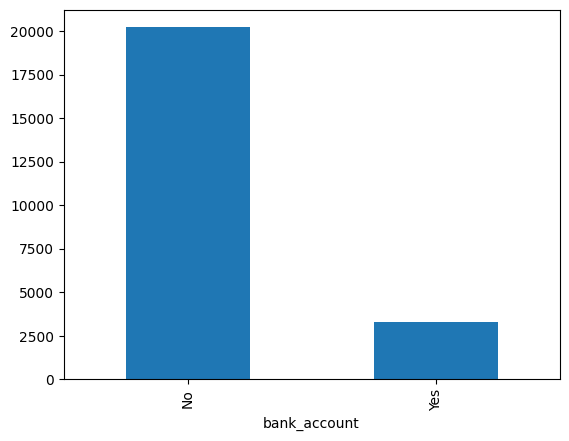

In [10]:
# first Plot
train_df["bank_account"].value_counts().plot(
    kind="bar"
)

## 3.2 Hypothesis 1 — Cellphone Access

The first hypothesis investigates whether access to a cellphone is associated with owning a bank account.

In many African countries, mobile devices play an important role in accessing financial services. Therefore, cellphone ownership may be an important indicator of financial inclusion.

The following analysis compares respondents with and without cellphone access.

In [11]:
# Hypothesis 1: Mobile Phone
pd.crosstab(
    train_df["cellphone_access"],
    train_df["bank_account"]
)

bank_account,No,Yes
cellphone_access,,
No,5966,104
Yes,14246,3208


<Axes: xlabel='cellphone_access'>

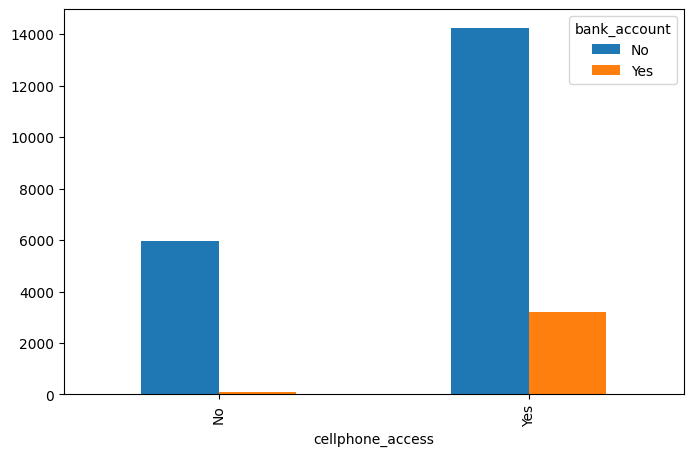

In [12]:
# visualisation:
pd.crosstab(
    train_df["cellphone_access"],
    train_df["bank_account"]
).plot(
    kind="bar",
    figsize=(8,5)
)

### Interpretation

The results show a strong relationship between cellphone access and bank account ownership.

Respondents without cellphone access rarely own a bank account, whereas respondents with cellphone access are considerably more likely to have one.

This observation supports the hypothesis that access to mobile technology is associated with greater financial inclusion.

## 3.3 Hypothesis 2 — Education Level

Education is expected to influence financial inclusion.

People with higher educational attainment may have better financial knowledge, greater employment opportunities and easier access to banking services.

The following analysis investigates whether education level is associated with owning a bank account.

# Hyputhesis 2: Education and Bank account

In [85]:
# Hyputhesis 2: Education and Bank account

# Show available education levels
train_df["education_level"].value_counts()


education_level
Primary education                  12791
No formal education                 4515
Secondary education                 4223
Tertiary education                  1157
Vocational/Specialised training      803
Other/Dont know/RTA                   35
Name: count, dtype: int64

In [ ]:
#  Show available education levels
pd.crosstab(
    train_df["education_level"],
    train_df["bank_account"]
)

bank_account,No,Yes
education_level,,
No formal education,4339,176
Other/Dont know/RTA,24,11
Primary education,11698,1093
Secondary education,3240,983
Tertiary education,566,591
Vocational/Specialised training,345,458


<Axes: xlabel='education_level'>

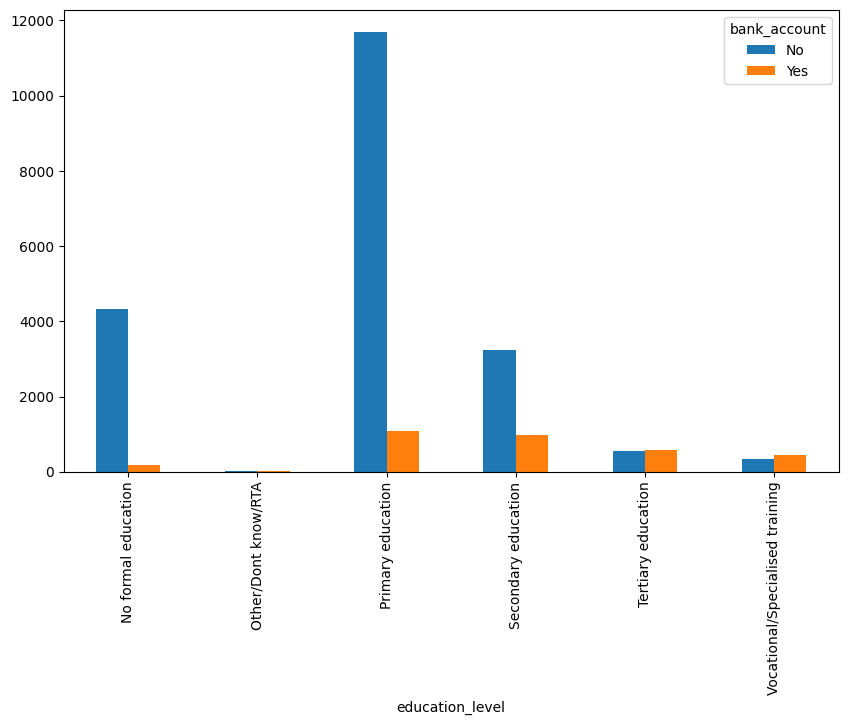

In [ ]:
# Visualisation: education level vs. bank account
pd.crosstab(
    train_df["education_level"],
    train_df["bank_account"]
).plot(
    kind="bar",
    figsize=(10,6)
)

### Interpretation

The analysis indicates that respondents with higher education levels are more likely to own a bank account.

Individuals with tertiary or vocational education show noticeably higher proportions of bank account ownership than respondents with no formal education.

Education therefore appears to be an important predictor of financial inclusion.

## 3.4 Hypothesis 3 — Location Type

This hypothesis investigates whether respondents living in urban areas are more likely to own or use a bank account than respondents living in rural areas.

Urban areas may provide easier access to banks, financial services and digital infrastructure. Therefore, location type may be associated with financial inclusion.

In [ ]:
# Cross table: location type vs. bank account
pd.crosstab(
    train_df["location_type"],
    train_df["bank_account"]
)

bank_account,No,Yes
location_type,,
Rural,12672,1671
Urban,7540,1641


<Axes: xlabel='location_type'>

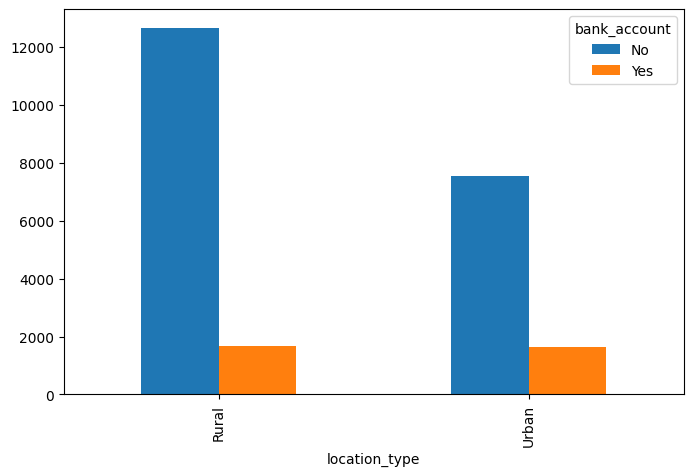

In [ ]:
# Visualisation with absolute counts
pd.crosstab(
    train_df["location_type"],
    train_df["bank_account"]
).plot(
    kind="bar",
    figsize=(8,5)
)

### Interpretation

The plot shows that rural respondents make up a large share of people without a bank account. The absolute number of bank account owners appears similar between rural and urban areas, while the number of non-owners is much higher in rural areas.

This suggests that location type may be related to financial inclusion. However, because the plot shows absolute counts, we need to compare relative proportions before drawing stronger conclusions.

In [ ]:
# Relative proportions by location type
location_account_share = pd.crosstab(
    train_df["location_type"],
    train_df["bank_account"],
    normalize="index"
)

location_account_share

bank_account,No,Yes
location_type,,
Rural,0.883497,0.116503
Urban,0.821261,0.178739


<Axes: xlabel='location_type'>

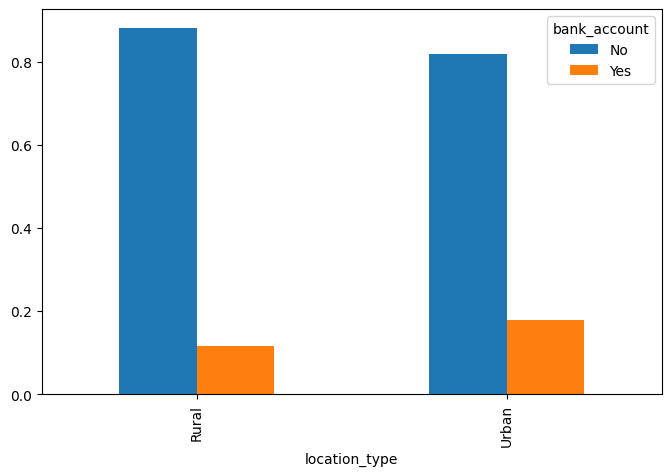

In [ ]:
# Visualisation with relative proportions
location_account_share.plot(
    kind="bar",
    figsize=(8, 5)
)

### Interpretation

Respondents living in urban areas show a higher proportion of bank account ownership than respondents living in rural areas.

Approximately 17.9% of urban respondents own a bank account, compared to only 11.7% of rural respondents.

This suggests that access to financial services may be easier in urban regions.

## 3.5 Age of Respondents

This section investigates whether age is related to bank account ownership.

Age is a numerical feature. Therefore, the analysis first looks at the overall age distribution and then compares the age distribution between respondents with and without a bank account.

<Axes: >

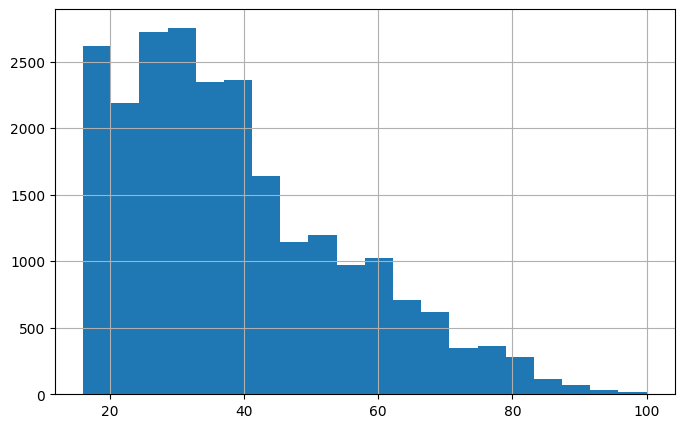

In [20]:
# hypotesis with age:of_responsent
train_df["age_of_respondent"].hist(
    bins=20,
    figsize=(8,5)
)

In [ ]:
# Descriptive statistics for age
train_df["age_of_respondent"].describe()

count    23524.000000
mean        38.805220
std         16.520569
min         16.000000
25%         26.000000
50%         35.000000
75%         49.000000
max        100.000000
Name: age_of_respondent, dtype: float64

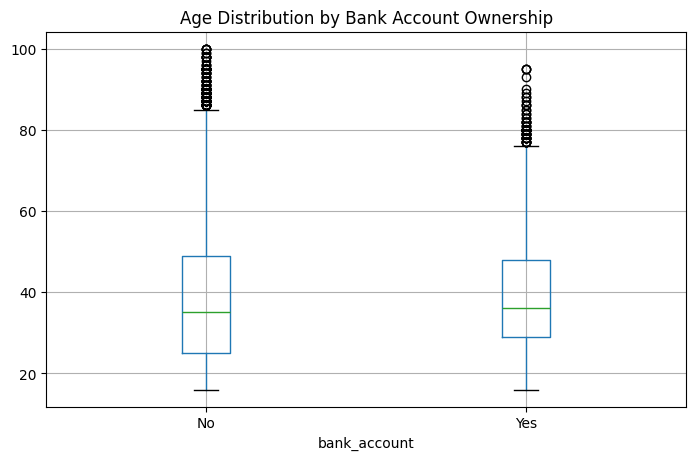

In [86]:
# Age distribution by bank account ownership
import matplotlib.pyplot as plt

train_df.boxplot(
    column="age_of_respondent",
    by="bank_account",
    figsize=(8,5)
)

plt.title("Age Distribution by Bank Account Ownership")
plt.suptitle("")
plt.show()

In [ ]:
# Descriptive age statistics by bank account ownership
train_df.groupby("bank_account")["age_of_respondent"].describe()

,count,mean,std,min,25%,50%,75%,max
bank_account,,,,,,,,
No,20212.0,38.675292,16.849093,16.0,25.0,35.0,49.0,100.0
Yes,3312.0,39.598128,14.330420,16.0,29.0,36.0,48.0,95.0


### Interpretation

Respondents with a bank account are slightly older on average than respondents without a bank account. However, the distributions overlap strongly, and the difference between the medians is small.

This suggests that age may provide some information for prediction, but it is likely not one of the strongest individual predictors.

## 3.6 Country Comparison

The next analysis investigates whether bank account ownership differs across the four participating countries.

Since the competition combines data from Kenya, Rwanda, Tanzania and Uganda, country-specific differences may provide valuable information for the prediction model.

In [87]:
# Hypothesis 4: Country comparison
train_df["country"].value_counts()

country
Rwanda      8735
Tanzania    6620
Kenya       6068
Uganda      2101
Name: count, dtype: int64

In [ ]:
# Cross table: country vs. bank account
pd.crosstab(
    train_df["country"],
    train_df["bank_account"]
)

bank_account,No,Yes
country,,
Kenya,4547,1521
Rwanda,7732,1003
Tanzania,6013,607
Uganda,1920,181


In [ ]:
# Relative proportions by country
country_account_share = pd.crosstab(
    train_df["country"],
    train_df["bank_account"],
    normalize="index"
)

country_account_share.round(3)

bank_account,No,Yes
country,,
Kenya,0.749,0.251
Rwanda,0.885,0.115
Tanzania,0.908,0.092
Uganda,0.914,0.086


<Axes: xlabel='country'>

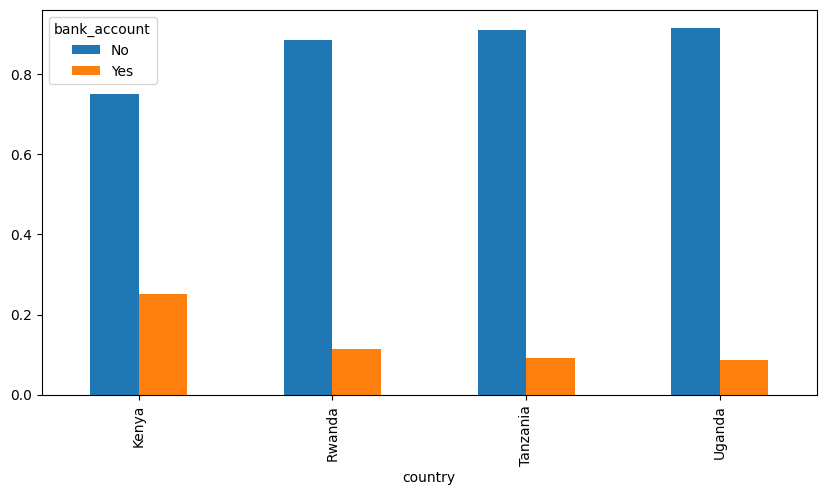

In [ ]:
# Visualisation of relative proportions
country_account_share.plot(
    kind="bar",
    figsize=(10, 5)
)

### Interpretation

The comparison shows noticeable differences between the four countries.

Kenya has the highest proportion of respondents with a bank account, while Tanzania and Uganda show considerably lower ownership rates.

Although country alone is not sufficient to predict financial inclusion, it appears to provide useful additional information for the machine learning model.

## 3.7 Household Size

This section investigates whether household size is associated with bank account ownership.

Household size may reflect different economic situations and could therefore influence financial inclusion.

<Axes: >

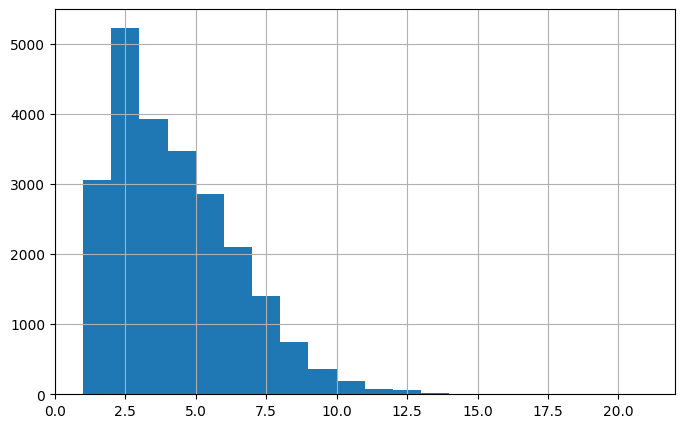

In [ ]:
# Hypothesis 5: Household size
train_df["household_size"].hist(
    bins=20,
    figsize=(8,5)
)

In [ ]:
# Distribution of household size
train_df["household_size"].describe()

count    23524.000000
mean         3.797483
std          2.227613
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         21.000000
Name: household_size, dtype: float64

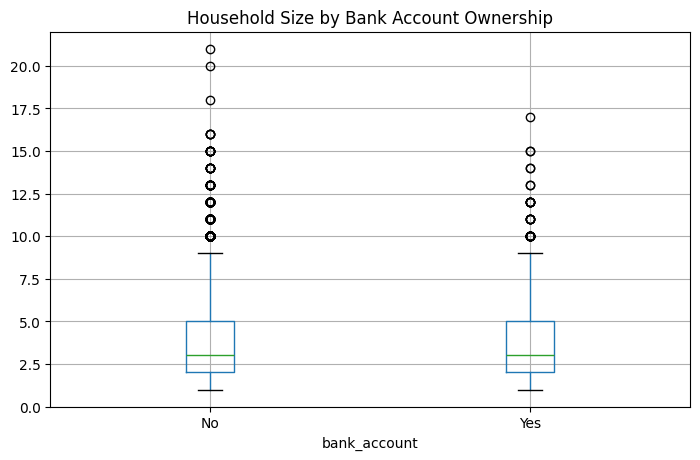

In [ ]:
# Household size grouped by bank account ownership
train_df.boxplot(
    column="household_size",
    by="bank_account",
    figsize=(8,5)
)

plt.title("Household Size by Bank Account Ownership")
plt.suptitle("")
plt.show()

### Interpretation

The distribution of household size is slightly right-skewed, with most households consisting of two to five members.

The comparison between respondents with and without a bank account shows only small differences.

Household size therefore appears to have only a moderate influence on financial inclusion compared with variables such as age, education level or cellphone access.

# 4 Machine Learning

After exploring and understanding the dataset, the next step is to build predictive machine learning models.

The objective is to predict whether a respondent owns a bank account based on the available demographic and socio-economic features.

Several classification models will be developed and compared before selecting the final model for submission to Zindi.

In [88]:
# Prepare the data for machine learning
target = "bank_account"

features = [
    "country",
    "year",
    "location_type",
    "cellphone_access",
    "household_size",
    "age_of_respondent",
    "gender_of_respondent",
    "relationship_with_head",
    "marital_status",
    "education_level",
    "job_type"
]

X = train_df[features]
y = train_df[target]

In [ ]:
# Convert the target variable into numerical values
y = y.map({
    "No": 0,
    "Yes": 1
})

In [ ]:
# Separate features and target variable
X.head()

,country,year,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [ ]:
# Verify feature data types
X.dtypes

country                   object
year                       int64
location_type             object
cellphone_access          object
household_size             int64
age_of_respondent          int64
gender_of_respondent      object
relationship_with_head    object
marital_status            object
education_level           object
job_type                  object
dtype: object

In [ ]:
# Define preprocessing for categorical and numerical features

numeric_features = [
    "year",
    "household_size",
    "age_of_respondent"
]


categorical_features = [
    "country",
    "location_type",
    "cellphone_access",
    "gender_of_respondent",
    "relationship_with_head",
    "marital_status",
    "education_level",
    "job_type"
]

## 4.1 Data Preparation

Before training any machine learning model, the data must be prepared.

Since the dataset contains both categorical and numerical variables, different preprocessing techniques are required.

Categorical variables are transformed using One-Hot Encoding, while numerical variables are passed through unchanged.

In [ ]:
# Define the preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        
        
        ("numeric", "passthrough", numeric_features)
    ]
)

## 4.2 Train-Test Split

To evaluate the model fairly, the dataset is divided into a training set and a validation set.

The model is trained using the training data and evaluated on previously unseen validation data.

In [ ]:
# Split the dataset into training and validation sets
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
# Build Dummy-Model
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

In [39]:
# train Dummy
dummy_model.fit(
    X_train,
    y_train
)

,strategy,'most_frequent'
,random_state,None
,constant,None


In [40]:
X_train.shape


(18819, 11)

In [41]:
y_train.shape

(18819,)

In [42]:
X_valid.shape

(4705, 11)

In [43]:
y_valid.shape

(4705,)

## 4.3 Baseline Model

Before training complex machine learning models, a simple baseline is created.

The Dummy Classifier predicts the majority class and serves as a reference point.

Any useful machine learning model should outperform this baseline.

In [ ]:
# Dummy-Baseline Pipline
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, mean_absolute_error, classification_report, confusion_matrix

# Die Pipeline verbindet zwei Schritte:
# 1. preprocessor: wandelt Textspalten per OneHotEncoding in Zahlen um
# 2. dummy_model: sagt immer die häufigste Klasse vorher
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]
)

# fit() bedeutet:
# Die Pipeline lernt aus den Trainingsdaten.
# Der Preprocessor merkt sich die Kategorien.
# Der DummyClassifier merkt sich die häufigste Zielklasse.
dummy_pipeline.fit(X_train, y_train)

# predict() bedeutet:
# Das Modell macht Vorhersagen auf den Validierungsdaten,
# die es beim Training noch nicht gesehen hat.
dummy_predictions = dummy_pipeline.predict(X_valid)

# Accuracy:
# Anteil der korrekt vorhergesagten Fälle.
dummy_accuracy = accuracy_score(y_valid, dummy_predictions)

# MAE:
# Mean Absolute Error.
# Bei 0/1-Klassen bedeutet das praktisch:
# Wie groß ist der durchschnittliche Fehler?
dummy_mae = mean_absolute_error(y_valid, dummy_predictions)

print("Dummy Baseline Accuracy:", dummy_accuracy)
print("Dummy Baseline MAE:", dummy_mae)

print("\nClassification Report:")
print(classification_report(y_valid, dummy_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, dummy_predictions))

Dummy Baseline Accuracy: 0.859298618490967
Dummy Baseline MAE: 0.14070138150903294

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92      4043
           1       0.00      0.00      0.00       662

    accuracy                           0.86      4705
   macro avg       0.43      0.50      0.46      4705
weighted avg       0.74      0.86      0.79      4705


Confusion Matrix:
[[4043    0]
 [ 662    0]]


x:\DEV\Neue_Fische\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
x:\DEV\Neue_Fische\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
x:\DEV\Neue_Fische\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


First real Model

### Baseline Interpretation

The dummy baseline always predicts the majority class (`No`). Because the dataset is strongly imbalanced, this already results in a high accuracy of about 86%.

However, the model fails to identify any respondents with a bank account. The recall for class `1` is 0.00, meaning that all actual account owners are misclassified as non-account owners.

This confirms that accuracy alone is not sufficient for this project. We also need to consider MAE, recall, F1-score and the confusion matrix.

In [ ]:
# Logistic Regression (initial model)
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

logistic_pipeline.fit(X_train, y_train)

logistic_predictions = logistic_pipeline.predict(X_valid)

logistic_accuracy = accuracy_score(y_valid, logistic_predictions)
logistic_mae = mean_absolute_error(y_valid, logistic_predictions)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Logistic Regression MAE:", logistic_mae)

print("\nClassification Report:")
print(classification_report(y_valid, logistic_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, logistic_predictions))

Logistic Regression Accuracy: 0.7906482465462275
Logistic Regression MAE: 0.20935175345377258

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      4043
           1       0.38      0.76      0.51       662

    accuracy                           0.79      4705
   macro avg       0.67      0.78      0.69      4705
weighted avg       0.87      0.79      0.82      4705


Confusion Matrix:
[[3217  826]
 [ 159  503]]


x:\DEV\Neue_Fische\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 4.4 Logistic Regression

Logistic Regression is used as the first real machine learning model.

A preprocessing pipeline is combined with the classifier to ensure that categorical variables are encoded and numerical variables are scaled consistently.

In [ ]:
# Improve the preprocessing pipeline
from sklearn.preprocessing import StandardScaler

numeric_features = [
    "year",
    "household_size",
    "age_of_respondent"
]

categorical_features = [
    "country",
    "location_type",
    "cellphone_access",
    "gender_of_respondent",
    "relationship_with_head",
    "marital_status",
    "education_level",
    "job_type"
]

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", StandardScaler(), numeric_features)
    ]
)


In [ ]:
# Train the Logistic Regression model
logistic_scaled_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]
)

logistic_scaled_pipeline.fit(X_train, y_train)

logistic_scaled_predictions = logistic_scaled_pipeline.predict(X_valid)

print("Logistic Regression Scaled Accuracy:", accuracy_score(y_valid, logistic_scaled_predictions))
print("Logistic Regression Scaled MAE:", mean_absolute_error(y_valid, logistic_scaled_predictions))

print("\nClassification Report:")
print(classification_report(y_valid, logistic_scaled_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, logistic_scaled_predictions))

Logistic Regression Scaled Accuracy: 0.7910733262486717
Logistic Regression Scaled MAE: 0.20892667375132837

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      4043
           1       0.38      0.76      0.51       662

    accuracy                           0.79      4705
   macro avg       0.67      0.78      0.69      4705
weighted avg       0.87      0.79      0.82      4705


Confusion Matrix:
[[3218  825]
 [ 158  504]]


## 4.5 Decision Tree

Decision Trees classify observations by repeatedly splitting the data into smaller groups.

The model is easy to interpret and provides a useful comparison with Logistic Regression.

### Scaled Logistic Regression Interpretation

Scaling the numerical features removed the convergence issue and made the Logistic Regression pipeline technically more stable.

The model performance changed only slightly compared to the unscaled version. Accuracy and MAE remained almost identical.

The model still detects a high proportion of actual bank account owners, but precision for class 1 remains low. This means the model identifies many true account owners, but also produces many false positive predictions.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Train the Decision Tree classifier
tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42,
            max_depth=5,
            class_weight="balanced"
        ))
    ]
)

tree_pipeline.fit(X_train, y_train)

tree_predictions = tree_pipeline.predict(X_valid)

print("Decision Tree Accuracy:", accuracy_score(y_valid, tree_predictions))
print("Decision Tree MAE:", mean_absolute_error(y_valid, tree_predictions))

print("\nClassification Report:")
print(classification_report(y_valid, tree_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, tree_predictions))

Decision Tree Accuracy: 0.6981934112646121
Decision Tree MAE: 0.3018065887353879

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.68      0.79      4043
           1       0.30      0.83      0.44       662

    accuracy                           0.70      4705
   macro avg       0.63      0.75      0.62      4705
weighted avg       0.87      0.70      0.74      4705


Confusion Matrix:
[[2736 1307]
 [ 113  549]]


### Decision Tree Interpretation

The Decision Tree achieved lower overall accuracy than Logistic Regression.

However, the model identified 83% of all actual bank account owners, which is higher than Logistic Regression.

The drawback is a very low precision score. Many respondents predicted as account owners actually do not own a bank account.

This suggests that the Decision Tree is aggressive in predicting the minority class and produces many false positives.

## 4.6 Random Forest

Random Forest combines many decision trees into an ensemble model.

Instead of relying on a single tree, multiple trees vote on the final prediction, resulting in a more robust and often more accurate classifier.

In [ ]:
# Train the Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [ ]:
# Generate predictions using the Random Forest model
forest_pipeline.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Random Forest Prediction and Evaluation

After training the Random Forest model, predictions are generated for the validation set.

The model is then evaluated using accuracy, MAE, precision, recall, F1-score and the confusion matrix.

In [ ]:
# Generate validation predictions with the Random Forest model
forest_predictions = forest_pipeline.predict(X_valid)

In [ ]:
# Evaluate the Random Forest model
print(
    "Random Forest Accuracy:",
    accuracy_score(y_valid, forest_predictions)
)

print(
    "Random Forest MAE:",
    mean_absolute_error(y_valid, forest_predictions)
)

print("\nClassification Report:")
print(classification_report(y_valid, forest_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, forest_predictions))

Random Forest Accuracy: 0.8544102019128587
Random Forest MAE: 0.14558979808714134

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.92      4043
           1       0.48      0.45      0.46       662

    accuracy                           0.85      4705
   macro avg       0.70      0.68      0.69      4705
weighted avg       0.85      0.85      0.85      4705


Confusion Matrix:
[[3725  318]
 [ 367  295]]


## 4.7 Model Comparison

The trained models are compared using several evaluation metrics.

Accuracy and MAE provide an overall view of model performance, while precision, recall and F1-score for class `1` show how well the models identify respondents with a bank account.

In [ ]:
# Compare all evaluated models
model_comparison = pd.DataFrame({
    "model": [
        "Dummy Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "accuracy": [
        dummy_accuracy,
        logistic_accuracy,
        accuracy_score(y_valid, tree_predictions),
        accuracy_score(y_valid, forest_predictions)
    ],
    "mae": [
        dummy_mae,
        logistic_mae,
        mean_absolute_error(y_valid, tree_predictions),
        mean_absolute_error(y_valid, forest_predictions)
    ],
    "recall_class_1": [
        0.00,
        0.76,
        0.83,
        0.45
    ],
    "precision_class_1": [
        0.00,
        0.38,
        0.30,
        0.48
    ],
    "f1_class_1": [
        0.00,
        0.51,
        0.44,
        0.46
    ]
})

model_comparison

,model,accuracy,mae,recall_class_1,precision_class_1,f1_class_1
0,Dummy Baseline,0.859299,0.140701,0.00,0.00,0.00
1,Logistic Regression,0.790648,0.209352,0.76,0.38,0.51
2,Decision Tree,0.698193,0.301807,0.83,0.30,0.44
3,Random Forest,0.854410,0.145590,0.45,0.48,0.46


## 4.8 Cross Validation

Cross validation is used to check whether the model performance is stable across different train-validation splits.

Instead of relying on one single split, the Random Forest model is evaluated across five folds.

In [ ]:
# Perform cross validation for the Random Forest model
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    forest_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

In [ ]:
# Display cross validation results
print("Cross Validation Scores:")
print(cv_scores)

print("\nMean Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross Validation Scores:
[0.63804463 0.81253985 0.85143464 0.83209352 0.87308673]

Mean Accuracy:
0.8014398761630052

Standard Deviation:
0.08413514092391051


### Cross Validation Interpretation

The Random Forest model achieved an average accuracy of approximately 80%.

The individual fold scores varied between 64% and 87%, indicating that model performance depends on the specific train-test split.

Overall, the model shows acceptable generalization performance, but the relatively high standard deviation suggests some instability across folds.

## 4.9 Feature Importance

After evaluating the Random Forest model, the next step is to inspect which features were most important for its predictions.

Feature importance helps to understand which variables the model used most often and most effectively when making decisions.

Because categorical variables were transformed with One-Hot Encoding, the feature names first need to be retrieved from the preprocessing pipeline.

In [ ]:
# Retrieve feature names after One-Hot Encoding
feature_names = (
    forest_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print(feature_names)
print(len(feature_names))

['categorical__country_Kenya' 'categorical__country_Rwanda'
 'categorical__country_Tanzania' 'categorical__country_Uganda'
 'categorical__location_type_Rural' 'categorical__location_type_Urban'
 'categorical__cellphone_access_No' 'categorical__cellphone_access_Yes'
 'categorical__gender_of_respondent_Female'
 'categorical__gender_of_respondent_Male'
 'categorical__relationship_with_head_Child'
 'categorical__relationship_with_head_Head of Household'
 'categorical__relationship_with_head_Other non-relatives'
 'categorical__relationship_with_head_Other relative'
 'categorical__relationship_with_head_Parent'
 'categorical__relationship_with_head_Spouse'
 'categorical__marital_status_Divorced/Seperated'
 'categorical__marital_status_Dont know'
 'categorical__marital_status_Married/Living together'
 'categorical__marital_status_Single/Never Married'
 'categorical__marital_status_Widowed'
 'categorical__education_level_No formal education'
 'categorical__education_level_Other/Dont know/RTA'


In [ ]:
# Create a feature importance table
# Feature Importances aus dem trainierten Forest holen
importances = forest_pipeline.named_steps["model"].feature_importances_

# DataFrame erzeugen
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Nach Wichtigkeit sortieren
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df.head(15)

,feature,importance
39,numeric__age_of_respondent,0.294350
38,numeric__household_size,0.127611
6,categorical__cellphone_access_No,0.050032
7,categorical__cellphone_access_Yes,0.047221
23,categorical__education_level_Primary education,0.042069
21,categorical__education_level_No formal education,0.035549
30,categorical__job_type_Formally employed Private,0.030863
25,categorical__education_level_Tertiary education,0.026154
0,categorical__country_Kenya,0.025325
4,categorical__location_type_Rural,0.020047


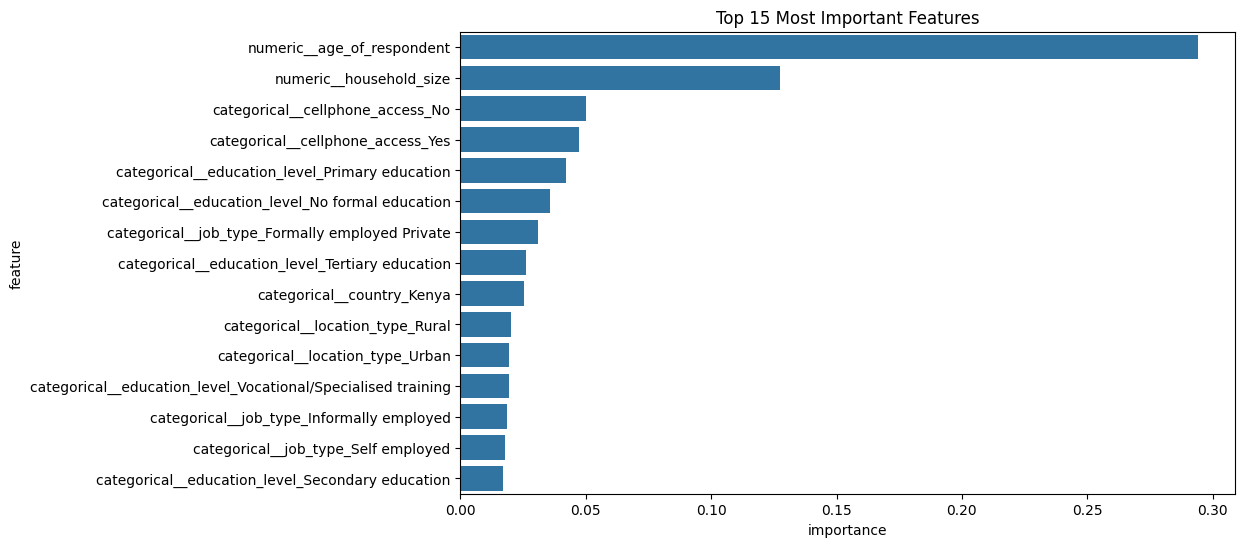

In [ ]:
import seaborn as sns

# Visualise the top 15 most important encoded features
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_df.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 Most Important Features")
plt.show()

### Grouping One-Hot-Encoded Features

The first feature importance table shows encoded features separately.

For a clearer interpretation, the encoded features are grouped back to their original feature names.

In [ ]:
# First attempt to group encoded feature names
feature_importance_grouped = feature_importance_df.copy()

feature_importance_grouped["original_feature"] = (
    feature_importance_grouped["feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numeric__", "", regex=False)
    .str.split("_")
    .str[:2]
    .str.join("_")
)

feature_importance_grouped_summary = (
    feature_importance_grouped
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

feature_importance_grouped_summary


original_feature
age_of               0.294350
education_level      0.140292
household_size       0.127611
job_type             0.121017
cellphone_access     0.097253
relationship_with    0.042521
marital_status       0.041247
location_type        0.039406
gender_of            0.026984
country_Kenya        0.025325
year                 0.016576
country_Tanzania     0.011621
country_Rwanda       0.008184
country_Uganda       0.007612
Name: importance, dtype: float64

<Axes: ylabel='original_feature'>

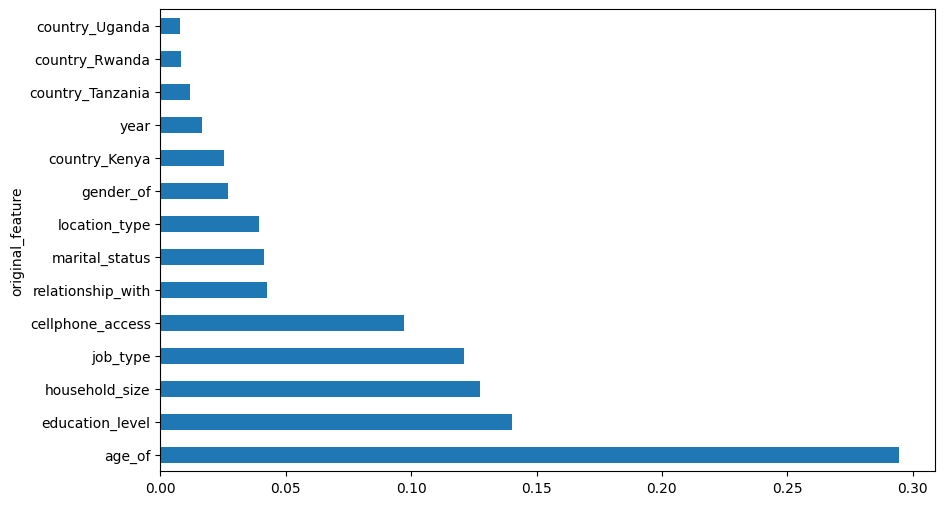

In [ ]:
# Plot grouped feature importance from the first attempt
feature_importance_grouped_summary.plot(
    kind="barh",
    figsize=(10, 6)
)

### Improved Grouping of Feature Importance

The previous grouping approach was too rough for feature names containing multiple words.

The following helper function maps each encoded feature back to its original feature name more reliably.

In [ ]:
# Helper function to map encoded features back to original feature names
def map_to_original_feature(encoded_feature):
    # Entfernt den technischen Prefix aus dem ColumnTransformer.
    # Aus "categorical__country_Kenya" wird "country_Kenya".
    feature = (
        encoded_feature
        .replace("categorical__", "")
        .replace("numeric__", "")
    )

    # Numerische Features wurden nicht durch OneHotEncoding aufgeteilt.
    # Deshalb können wir sie direkt zurückgeben.
    if feature in numeric_features:
        return feature

    # Kategorische Features wurden beim OneHotEncoding erweitert.
    # Wir prüfen daher: Beginnt der erzeugte Feature-Name mit dem Originalnamen?
    for original_feature in categorical_features:
        if feature.startswith(original_feature + "_"):
            return original_feature

    # Falls nichts passt, geben wir den Namen unverändert zurück.
    # Das ist eine Sicherheitsleine, falls später unerwartete Namen auftauchen.
    return feature

In [ ]:
# Apply the mapping function and aggregate feature importances
feature_importance_df["original_feature"] = feature_importance_df["feature"].apply(
    map_to_original_feature
)

# group by:
feature_importance_grouped_summary = (
    feature_importance_df
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

feature_importance_grouped_summary


original_feature
age_of_respondent         0.294350
education_level           0.140292
household_size            0.127611
job_type                  0.121017
cellphone_access          0.097253
country                   0.052743
relationship_with_head    0.042521
marital_status            0.041247
location_type             0.039406
gender_of_respondent      0.026984
year                      0.016576
Name: importance, dtype: float64

### Feature Importance Interpretation

The grouped feature importance shows that age, education level, household size, job type and cellphone access are the most important features in the Random Forest model.

This means that the model used these variables most frequently and effectively for its decision splits.

However, feature importance does not imply causality. It only describes which variables were useful for prediction within this model.

## 4.10 Hyperparameter Tuning

After comparing the initial models, the Random Forest model is further optimized using hyperparameter tuning.

GridSearchCV tests different combinations of model parameters and evaluates them using cross validation.

The goal is to identify the parameter combination that performs best on the training data.

In [89]:
# Hyperparameter tuning for the Random Forest model
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}

forest_grid_search = GridSearchCV(
    estimator=forest_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

forest_grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(forest_grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(forest_grid_search.best_score_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best Cross Validation Score:
0.8544024655932834


### Interpretation

GridSearchCV selected the best-performing Random Forest configuration from the predefined parameter grid.

The result shows which combination of `n_estimators`, `max_depth` and `min_samples_split` achieved the best cross-validation score.

The improvement compared with the initial Random Forest model was limited, which suggests that the model was already reasonably well configured.

## 4.11 Correlation Matrix

A correlation matrix is used to inspect linear relationships between numerical variables.

Since most features in this dataset are categorical, the correlation matrix is limited to numerical features and the encoded target variable.

This analysis helps compare simple linear relationships with the more complex patterns detected by the Random Forest model.

In [ ]:
# Prepare numerical variables for correlation analysis
correlation_df = train_df.copy()

correlation_df["bank_account"] = (
    correlation_df["bank_account"]
    .map({"No": 0, "Yes": 1})
)

correlation_df[
    [
        "age_of_respondent",
        "household_size",
        "year",
        "bank_account"
    ]
].corr()

,age_of_respondent,household_size,year,bank_account
age_of_respondent,1.000000,-0.129729,-0.019330,0.019429
household_size,-0.129729,1.000000,-0.052264,-0.028326
year,-0.019330,-0.052264,1.000000,0.112318
bank_account,0.019429,-0.028326,0.112318,1.000000


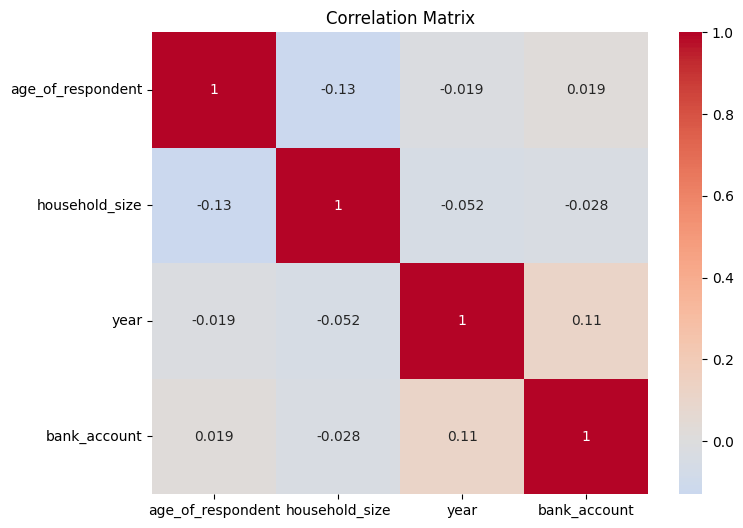

In [ ]:
# Visualise the correlation matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_df[
        [
            "age_of_respondent",
            "household_size",
            "year",
            "bank_account"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

# 5. Final Model

After model comparison, feature importance analysis and hyperparameter tuning, the Random Forest model is selected as the final model.

For the final training step, the model is trained on the complete training dataset instead of only the training split.

This allows the model to learn from all available labelled data before generating predictions for the Zindi test dataset.

In [ ]:
# Recreate features and target using the full training dataset

X = train_df.drop(
    columns=["bank_account", "uniqueid"]
)

y = train_df["bank_account"].map({
    "No": 0,
    "Yes": 1
})

In [ ]:
# Create the final Random Forest pipeline with selected parameters
final_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_split=2,
            random_state=42
        )
    )
])

In [ ]:
# Train the final model on the full training dataset
final_pipeline.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Final Model Training

The final pipeline contains the same preprocessing steps as before and a Random Forest classifier with the selected parameters.

Unlike the earlier evaluation phase, the model is now trained on the full training dataset, because no validation split is needed for the final submission.

# 6. Zindi Submission

After training the final model, predictions are generated for the unseen Zindi test dataset.

The test dataset does not contain the target variable `bank_account`. Therefore, the trained model is used to predict whether each respondent is likely to own or use a bank account.

The predictions are then saved in the submission format required by Zindi.

In [ ]:
# Load the Zindi test dataset
test_df = pd.read_csv("data/Test.csv")

test_df.head()

,country,year,uniqueid,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_6056,Urban,Yes,3,30,Male,Head of Household,Married/Living together,Secondary education,Formally employed Government
1,Kenya,2018,uniqueid_6060,Urban,Yes,7,51,Male,Head of Household,Married/Living together,Vocational/Specialised training,Formally employed Private
2,Kenya,2018,uniqueid_6065,Rural,No,3,77,Female,Parent,Married/Living together,No formal education,Remittance Dependent
3,Kenya,2018,uniqueid_6072,Rural,No,6,39,Female,Head of Household,Married/Living together,Primary education,Remittance Dependent
4,Kenya,2018,uniqueid_6073,Urban,No,3,16,Male,Child,Single/Never Married,Secondary education,Remittance Dependent


In [70]:
test_df.shape

(10086, 12)

In [ ]:
# Check the columns of the test dataset
test_df.columns


Index(['country', 'year', 'uniqueid', 'location_type', 'cellphone_access',
       'household_size', 'age_of_respondent', 'gender_of_respondent',
       'relationship_with_head', 'marital_status', 'education_level',
       'job_type'],
      dtype='object')

In [ ]:
# Compare test columns with the training feature columns
X.columns

Index(['country', 'year', 'location_type', 'cellphone_access',
       'household_size', 'age_of_respondent', 'gender_of_respondent',
       'relationship_with_head', 'marital_status', 'education_level',
       'job_type'],
      dtype='object')

In [ ]:
# Generate predictions for the test dataset
test_predictions = final_pipeline.predict(test_df)

In [ ]:
# Display raw model predictions
test_predictions

array([1, 1, 0, ..., 0, 0, 0], shape=(10086,))

In [ ]:
# Check the distribution of predicted classes
pd.Series(test_predictions).value_counts()

0    9046
1    1040
Name: count, dtype: int64

In [ ]:
# Create the submission DataFrame in the required Zindi format
submission = pd.DataFrame({
    "unique_id": test_df["uniqueid"] + " x " + test_df["country"],
    "bank_account": test_predictions
})
submission.head()

,unique_id,bank_account
0,uniqueid_6056 x Kenya,1
1,uniqueid_6060 x Kenya,1
2,uniqueid_6065 x Kenya,0
3,uniqueid_6072 x Kenya,0
4,uniqueid_6073 x Kenya,0


In [ ]:
# Verify the submission shape
submission.shape

(10086, 2)

In [ ]:
# Save the submission file as CSV
submission.to_csv(
    "submission_v1.csv",
    index=False
)

In [ ]:
# Inspect the first rows of the submission file #79
submission.head(10)

,unique_id,bank_account
0,uniqueid_6056 x Kenya,1
1,uniqueid_6060 x Kenya,1
2,uniqueid_6065 x Kenya,0
3,uniqueid_6072 x Kenya,0
4,uniqueid_6073 x Kenya,0
5,uniqueid_6074 x Kenya,0
6,uniqueid_6075 x Kenya,0
7,uniqueid_6076 x Kenya,0
8,uniqueid_6077 x Kenya,0
9,uniqueid_6078 x Kenya,1


In [ ]:
# Check the distribution of predictions in the submission file
submission["bank_account"].value_counts()

bank_account
0    9046
1    1040
Name: count, dtype: int64

In [ ]:
# Reload the saved CSV file to verify the final output
pd.read_csv("submission_v1.csv").head()

,unique_id,bank_account
0,uniqueid_6056 x Kenya,1
1,uniqueid_6060 x Kenya,1
2,uniqueid_6065 x Kenya,0
3,uniqueid_6072 x Kenya,0
4,uniqueid_6073 x Kenya,0


### Submission Result

The final submission file was successfully created and uploaded to Zindi.

The submission achieved a public MAE score of **0.13345231**.

Since the competition metric is Mean Absolute Error, lower values indicate better performance.

# 7. Conclusion

# 7. Conclusion

## Project Summary

The objective of this project was to predict whether a respondent owns or uses a bank account based on demographic and socio-economic characteristics.

The project followed a complete supervised machine learning workflow, including data exploration, preprocessing, model training, evaluation and the creation of a competition submission for the Zindi platform.

---

## Main Findings

The exploratory data analysis revealed several meaningful relationships:

- Respondents with cellphone access were considerably more likely to own a bank account.
- Higher education levels were associated with higher rates of financial inclusion.
- Urban respondents generally showed higher bank account ownership than rural respondents.
- Older respondents tended to own bank accounts more frequently than younger respondents.
- Country-specific differences indicated that financial inclusion varies across the participating countries.

---

## Model Performance

Several classification models were evaluated throughout the project.

- Dummy Classifier (Baseline)
- Logistic Regression
- Decision Tree
- Random Forest

Among these models, the Random Forest classifier achieved the best overall performance and was therefore selected as the final model.

Hyperparameter tuning produced only minor improvements, indicating that the initial Random Forest configuration was already well suited for this dataset.

The final submission achieved a public Zindi score (MAE) of **0.13345231**.

---

## Lessons Learned

This project demonstrates that successful machine learning is not only about selecting a model.

A structured workflow consisting of data exploration, preprocessing, feature engineering, model evaluation and interpretation is essential for building reliable predictive models.

The comparison between correlation analysis and feature importance also illustrates that machine learning models are able to capture complex non-linear relationships that cannot be identified by simple correlation coefficients alone.

---

## Possible Future Improvements

Several approaches could further improve the predictive performance:

- More extensive feature engineering
- Hyperparameter optimization using a larger search space
- Evaluation of Gradient Boosting methods such as XGBoost, LightGBM or CatBoost
- Investigation of class imbalance using alternative sampling techniques
- Ensemble methods combining multiple classifiers

---

Overall, this project provided a complete end-to-end machine learning workflow and demonstrates how predictive models can support the understanding of financial inclusion in Africa.

## Thank you for reading!

This notebook documents the complete machine learning workflow for the Zindi Financial Inclusion in Africa competition.

Thank you for taking the time to review this project.